# Reto 04 - Autoencoders

## Detección de anomalías en series de tiempo con autoencoders

> **Fuente del problema:** [Numenta Anomaly Benchmark (NAB)](https://www.kaggle.com/datasets/boltzmannbrain/nab)
> publicado en **Kaggle**, réplica del [repositorio original de Numenta](https://github.com/numenta/NAB), pensado para evaluar
> algoritmos de detección de anomalías en flujos de datos temporales (*streaming*).

### El problema

NAB es una colección de series de tiempo, tanto reales como artificiales, etiquetadas con la ubicación de sus anomalías, y diseñada
específicamente para evaluar algoritmos de detección de anomalías en condiciones cercanas a las de producción (datos que llegan de
forma continua, sin poder reentrenar el modelo con el conjunto completo de antemano). Dentro de esta colección, las series
**artificiales** (`artificialNoAnomaly/` y `artificialWithAnomaly/`) son señales sintéticas con un patrón periódico claro (una onda
con ruido leve) a las que se les inyectan anomalías controladas, lo que las vuelve ideales para un primer acercamiento a la técnica
sin la complejidad adicional de una serie real.

Un **autoencoder** aprende a reconstruir su propia entrada comprimiéndola a través de un cuello de botella. Si se entrena
únicamente con datos "normales", la red se especializa en reconstruir ese patrón y falla al reconstruir observaciones que se
desvían de él; el **error de reconstrucción** se convierte entonces en una señal de anomalía: valores altos indican secuencias que
el modelo no reconoce como parte del comportamiento habitual de la serie.

### Objetivo

1. Entrenar un **autoencoder** (rnn) sobre ventanas de la serie `art_daily_small_noise.csv`, que no contiene
   anomalías, para que aprenda a reconstruir el comportamiento normal de la serie.
2. Definir un **umbral de errorn** a partir del propio conjunto de entrenamiento.
3. Evaluar el modelo sobre `art_daily_jumpsup.csv`, una serie con el mismo patrón base pero que presenta un salto anómalo sostenido,
   y usar el umbral de error para **localizar la anomalía** en el tiempo.
4. Visualizar la serie original, el error de reconstrucción y los puntos marcados como anómalos para validar el resultado.

### Estructura de los datos

Usaremos únicamente dos archivos de la colección de series artificiales, cada uno con una columna `timestamp` y una columna
`value` muestreadas cada 5 minutos:

| Archivo | Carpeta en NAB | Uso | Contenido |
|---|---|---|---|
| `art_daily_small_noise.csv` | `artificialNoAnomaly/` | Entrenamiento | Serie diaria periódica con ruido leve, sin anomalías |
| `art_daily_jumpsup.csv` | `artificialWithAnomaly/` | Prueba | Misma serie base, con un salto anómalo sostenido inyectado |

La simplicidad de este conjunto de datos (una sola variable, un patrón periódico estable y una anomalía bien delimitada) permite
demostrar de forma clara el flujo completo de detección de anomalías con autoencoders, antes de enfrentarlo a series reales más
ruidosas.


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")


import mlflow
import keras
import pathlib
import logging
import warnings


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline

from numpy.lib.stride_tricks import sliding_window_view

tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

warnings.filterwarnings("ignore", category=UserWarning)

AUTOTUNE = tf.data.AUTOTUNE

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("reto-04-autoencoders")
mlflow.tensorflow.autolog(
    log_models=True,
    log_input_examples=True,
    log_model_signatures=True,
    log_every_n_steps=10,
    log_every_epoch=False,
)

print(
    "Keras:",
    keras.__version__,
    "| backend:",
    keras.backend.backend(),
    "| GPUs:",
    tf.config.list_physical_devices("GPU"),
)

2026/09/25 12:04:48 INFO mlflow.tracking.fluent: Experiment with name 'reto-04-autoencoders' does not exist. Creating a new experiment.


Keras: 3.15.1 | backend: tensorflow | GPUs: []


Columns: Index(['timestamp', 'value'], dtype='str')
Shape: (4032, 2) | Delta: 0 days 00:05:00
Max Date 2014-04-14 23:55:00 | Min Date 2014-04-01 00:00:00


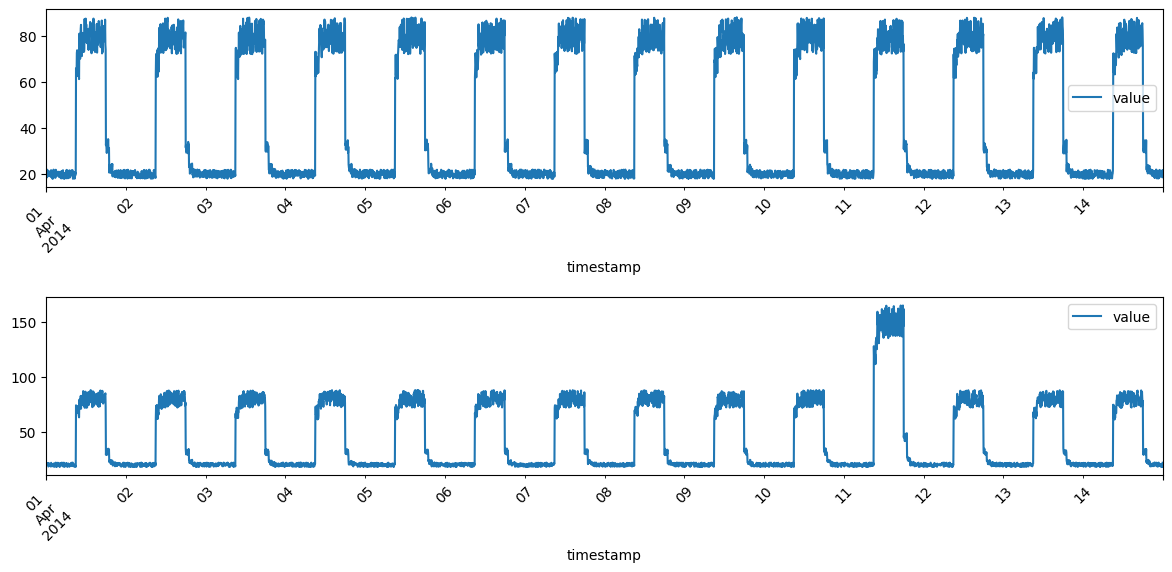

In [2]:
main_df = pd.read_csv(
    "../data/numenta-anomaly-benchmark/artificialNoAnomaly/artificialNoAnomaly/art_daily_small_noise.csv",
)

anomaly_df = pd.read_csv(
    "../data/numenta-anomaly-benchmark/artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsup.csv"
)

print("Columns:", main_df.columns)

main_df["timestamp"] = pd.to_datetime(main_df["timestamp"])
anomaly_df["timestamp"] = pd.to_datetime(anomaly_df["timestamp"])

delta = pd.to_datetime(main_df["timestamp"][1]) - pd.to_datetime(
    main_df["timestamp"][0]
)

print("Shape:", main_df.shape, "| Delta:", delta)

mint, maxt = main_df["timestamp"].min(), main_df["timestamp"].max()

print("Max Date", maxt, "| Min Date", mint)

fig, ax = plt.subplots(2, 1, figsize=(12, 6))

main_df.plot(x=main_df.columns[0], rot=45, ax=ax[0])
anomaly_df.plot(x=anomaly_df.columns[0], rot=45, ax=ax[1])
plt.tight_layout(pad=1.7)

In [3]:
WINDOW = 100
HORIZON = 20
SIZE = 3800

Shape: (3800, 100, 2) | Shape (3800, 20, 2)


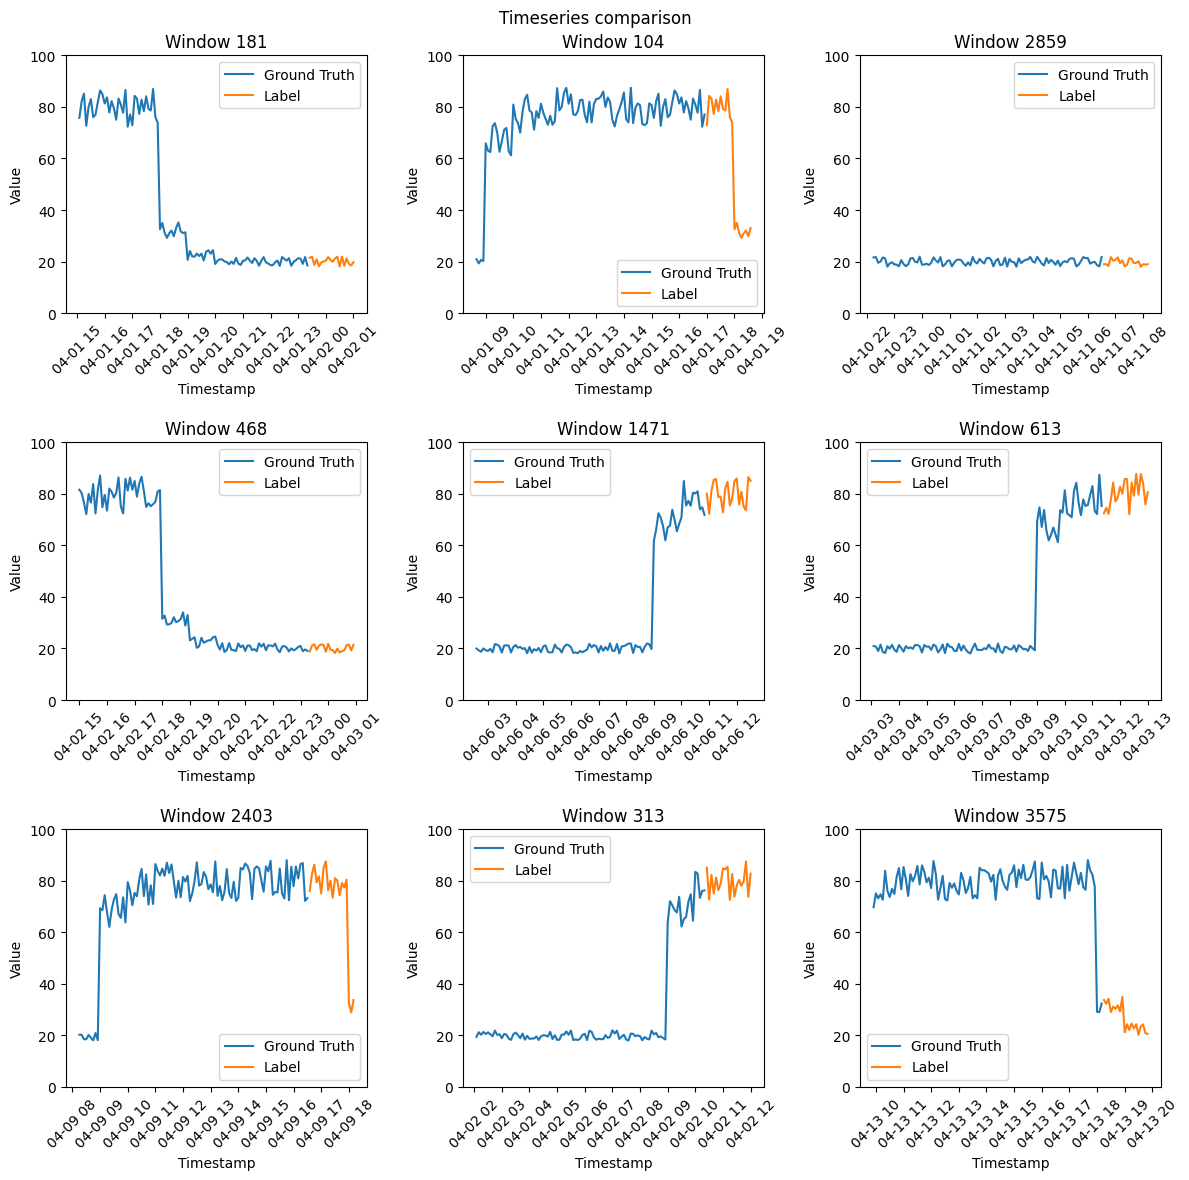

In [4]:
def make_sliding_window(
    dataframe,
    window: int = 10,
    horizon: int = 5,
    size: int = 100,
):
    X = sliding_window_view(
        dataframe, window_shape=(window, dataframe.shape[1])
    ).squeeze()

    y = sliding_window_view(
        dataframe, window_shape=(window + horizon, dataframe.shape[1])
    ).squeeze()

    # truncate the values from the window
    y = y[:, window:]

    return X[:size], y[:size]


X, y = make_sliding_window(main_df, window=WINDOW, horizon=HORIZON, size=SIZE)

print("Shape:", X.shape, "| Shape", y.shape)


def plot_timeseries(X, y, nrows: int = 2, ncols: int = 2):
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle("Timeseries comparison")

    axs = axs.ravel()

    for ax in axs:
        i = np.random.randint(0, X.shape[0])
        ax.set_title(f"Window {i}")
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", labelrotation=45)
        ax.plot(
            pd.date_range(X[i, :, 0][0], X[i, :, 0][-1], freq="5min"),
            X[i, :, 1],
            label="Ground Truth",
        )
        ax.plot(
            pd.date_range(y[i, :, 0][0], y[i, :, 0][-1], freq="5min"),
            y[i, :, 1],
            label="Label",
        )
        ax.legend()
        ax.set_ylabel("Value")
        ax.set_xlabel("Timestamp")

    plt.tight_layout(h_pad=1.7)


plot_timeseries(X, y, nrows=3, ncols=3)

In [5]:
def cyclic_transformer(period):
    def forward(x):
        x = np.asarray(x, dtype=float)
        angle = x / period * 2 * np.pi
        return np.hstack([np.sin(angle), np.cos(angle)])

    def inverse(x):
        x = np.asarray(x, dtype=float)
        n = x.shape[1] // 2
        angle = np.arctan2(x[:, :n], x[:, n:])
        return (angle / (2 * np.pi) * period) % period

    def names(input_features):
        return [f"{f}_sin" for f in input_features] + [
            f"{f}_cos" for f in input_features
        ]

    return FunctionTransformer(forward, inverse, feature_names_out=names)


def dt_part(attr):
    return FunctionTransformer(
        lambda x: getattr(pd.to_datetime(x["timestamp"]).dt, attr).to_frame(),
        inverse_func=lambda x: x,
        check_inverse=False,
        feature_names_out=lambda self, names: [attr],
    )

In [6]:
transform_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ("extract_hour", dt_part("hour"), ["timestamp"]),
            ("extract_min", dt_part("minute"), ["timestamp"]),
        ],
        remainder="passthrough",
    ),
    ColumnTransformer(
        transformers=[
            ("hour", cyclic_transformer(24), [0]),
            ("minute", cyclic_transformer(60), [1]),
            ("value", StandardScaler(), [2]),
        ],
        remainder="drop",
    ),
)

In [7]:
X_train, X_val = train_test_split(
    main_df,
    test_size=0.2,
    shuffle=False,
)

print("Shape:", X_train.shape, "| Shape:", X_val.shape)

Shape: (3225, 2) | Shape: (807, 2)


In [8]:
transform_pipeline.fit(X_train)

X_train_processed = transform_pipeline.transform(X_train)
X_val_processed = transform_pipeline.transform(X_val)
X_test_processed = transform_pipeline.transform(anomaly_df)

X_train_windows = sliding_window_view(
    X_train_processed,
    window_shape=(WINDOW, X_train_processed.shape[1]),
).squeeze()

X_val_windows = sliding_window_view(
    X_val_processed,
    window_shape=(WINDOW, X_val_processed.shape[1]),
).squeeze()

X_test_windows = sliding_window_view(
    X_test_processed,
    window_shape=(WINDOW, X_test_processed.shape[1]),
).squeeze()

X_train_windows.shape, X_val_windows.shape, X_test_windows.shape

((3126, 100, 5), (708, 100, 5), (3933, 100, 5))

## Build Model

In [9]:
def build_model(
    timesteps, features, latent_space=64, activation="tanh", init="glorot_uniform"
):
    inputs = keras.Input(shape=(timesteps, features), name="inputs")

    # Encoder
    x = keras.layers.LSTM(
        latent_space * 2,
        activation=activation,
        return_sequences=True,
        kernel_initializer=init,
        name="lstm_enc_2",
    )(inputs)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.LSTM(
        latent_space,
        activation=activation,
        return_sequences=False,
        kernel_initializer=init,
        name="lstm_enc_1",
    )(x)

    # Decoder
    d = keras.layers.RepeatVector(timesteps)(x)
    d = keras.layers.LSTM(
        latent_space,
        activation=activation,
        return_sequences=True,
        kernel_initializer=init,
        name="lstm_dec_1",
    )(d)
    d = keras.layers.Dropout(0.2)(d)
    d = keras.layers.LSTM(
        latent_space * 2,
        activation=activation,
        return_sequences=True,
        kernel_initializer=init,
        name="lstm_dec_2",
    )(d)

    # Output
    outs = keras.layers.TimeDistributed(
        keras.layers.Dense(
            features,
            kernel_initializer=init,
        ),
        name="timedistributed_dense",
    )(d)

    model = keras.Model(
        inputs,
        outs,
        name="autoencoder_timeseries",
    )

    extractor = keras.Model(
        inputs=model.inputs,
        outputs=x,
        name="extractor_timeseries",
    )

    return model, extractor


model, extractor = build_model(WINDOW, X_train_windows.shape[-1])
model.summary(), extractor.summary()

Model: "autoencoder_timeseries"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 100, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_2 (LSTM)               │ (None, 100, 128)       │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_1 (LSTM)               │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_1 (LSTM)               │ (None, 100, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_2 (LSTM)               │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ timedistributed_dense           │ (None, 100, 5)         │           645 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,501 (978.52 KB)

 Trainable params: 250,501 (978.52 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 100, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_2 (LSTM)               │ (None, 100, 128)       │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_1 (LSTM)               │ (None, 64)             │        49,408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,016 (461.00 KB)

 Trainable params: 118,016 (461.00 KB)

 Non-trainable params: 0 (0.00 B)

(None, None)

In [10]:
EPOCHS = 100
WARMUP_EPOCHS = 5

# Calculamos la cantidad de total de steps y ubicamos un 5% para warmup del lr
steps_per_epoch = int(np.ceil(X_train_windows.shape[0] / 32))
total_steps = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    warmup_target=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps - warmup_steps,
    alpha=0.01,
)

print(
    f"pasos/época: {steps_per_epoch} | warmup: {warmup_steps} | "
    f"decay: {total_steps - warmup_steps} | total: {total_steps}"
)

RUTA_MODELO = pathlib.Path(f"../models/reto-04-{model.name}.keras")
RUTA_MODELO.parent.mkdir(parents=True, exist_ok=True)


optim_fn = keras.optimizers.Adam(learning_rate=scheduler)  # type: ignore

stop_cb = keras.callbacks.EarlyStopping(
    patience=5,
    mode="min",
    restore_best_weights=True,
)
best_cb = keras.callbacks.ModelCheckpoint(
    filepath=RUTA_MODELO,
    save_best_only=True,
    mode="min",
)


class LearningRateLogger(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs={}):
        optim = self.model.optimizer  # type: ignore
        lr = optim.learning_rate
        if isinstance(lr, keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(optim.iterations)
        logs["learning_rate"] = float(keras.ops.convert_to_numpy(lr))  # type: ignore


lr_cb = LearningRateLogger()


model.compile(
    optimizer=optim_fn,
    loss=keras.losses.MeanSquaredError(),
    metrics=[
        keras.metrics.MeanAbsoluteError(),
        keras.metrics.MeanAbsolutePercentageError(),
    ],
)

with mlflow.start_run():
    history = model.fit(
        X_train_windows,
        X_train_windows,
        epochs=EPOCHS,
        shuffle=True,
        batch_size=32,
        callbacks=[best_cb, lr_cb, stop_cb],
        validation_data=(X_val_windows, X_val_windows),
    )

print("Modelo guardado en:", RUTA_MODELO.resolve())

pasos/época: 98 | warmup: 490 | decay: 9310 | total: 9800


Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.5149 - mean_absolute_error: 0.6292 - mean_absolute_percentage_error: 5814838.0000

98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 0.5149 - mean_absolute_error: 0.6292 - mean_absolute_percentage_error: 5814838.0000 - val_loss: 0.3976 - val_mean_absolute_error: 0.5262 - val_mean_absolute_percentage_error: 10469013.0000 - learning_rate: 6.8000e-05
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.3360 - mean_absolute_error: 0.4647 - mean_absolute_percentage_error: 12355486.0000

98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.3360 - mean_absolute_error: 0.4647 - mean_absolute_percentage_error: 12355486.0000 - val_loss: 0.2857 - val_mean_absolute_error: 0.4158 - val_mean_absolute_percentage_error: 10820978.0000 - learning_rate: 1.2600e-04
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2578 - mean_absolute_error: 0.3807 - mean_absolute_percentage_error: 8072927.5000

98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.2578 - mean_absolute_error: 0.3807 - mean_absolute_percentage_error: 8072927.5000 - val_loss: 0.2417 - val_mean_absolute_error: 0.3553 - val_mean_absolute_percentage_error: 5827136.5000 - learning_rate: 1.8400e-04
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2364 - mean_absolute_error: 0.3438 - mean_absolute_percentage_error: 5632659.5000

...

98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.1923 - mean_absolute_error: 0.2853 - mean_absolute_percentage_error: 7713874.5000 - val_loss: 0.1925 - val_mean_absolute_error: 0.2852 - val_mean_absolute_percentage_error: 8391542.0000 - learning_rate: 2.5208e-04
Epoch 31/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1893 - mean_absolute_error: 0.2832 - mean_absolute_percentage_error: 7990755.5000

98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.1893 - mean_absolute_error: 0.2832 - mean_absolute_percentage_error: 7990755.5000 - val_loss: 0.1826 - val_mean_absolute_error: 0.2759 - val_mean_absolute_percentage_error: 7429013.0000 - learning_rate: 2.4841e-04
Epoch 32/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1904 - mean_absolute_error: 0.2840 - mean_absolute_percentage_error: 8440201.0000

98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.1904 - mean_absolute_error: 0.2840 - mean_absolute_percentage_error: 8440201.0000 - val_loss: 0.1761 - val_mean_absolute_error: 0.2701 - val_mean_absolute_percentage_error: 7369334.0000 - learning_rate: 2.4464e-04
Epoch 33/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.1862 - mean_absolute_error: 0.2803 - mean_absolute_percentage_error: 8501686.0000 - val_loss: 0.1836 - val_mean_absolute_error: 0.2764 - val_mean_absolute_percentage_error: 8071019.0000 - learning_rate: 2.4076e-04
Epoch 34/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.2009 - mean_absolute_error: 0.2933 - mean_absolute_percentage_error: 9775872.0000 - val_loss: 0.2166 - val_mean_absolute_error: 0.3059 - val_mean_absolute_percentage_error: 10464853.0000 - learning_rate: 2.3679e-04
Epoch 35/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.1933 - mean_absolute_error: 0.2874 - mean_absolute_percentage_error: 8459775.0000 - val_loss: 0.1863 - val_mean_absolu

2026/09/25 12:09:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/25 12:09:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
🏃 View run merciful-wolf-347 at: http://127.0.0.1:5000/#/experiments/3/runs/f2b37d87dd974c5cb417dd214993ea17
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Modelo guardado en: /Users/jmanuelc87/Documents/Projects Single Repository/bourbaki-track-ciencia-datos/03-deep-learning/models/reto-04-autoencoder_timeseries.keras


In [11]:
LR_KEYS = ("learning_rate", "lr")


def plot_history(
    history,
    metrics=None,
    cols: int = 2,
    figsize_scale: float = 4.5,
    skip_first: int = 0,
    log_loss: bool = False,
):
    """Grafica entrenamiento vs. validación por época y devuelve el historial como DataFrame."""
    registro = history.history if hasattr(history, "history") else dict(history)
    df = pd.DataFrame(registro)
    df.index = np.arange(1, len(df) + 1)
    df.index.name = "epoch"

    if metrics is None:
        metrics = [k for k in df.columns if not k.startswith("val_")]
        orden = {k: i for i, k in enumerate(metrics)}
        metrics.sort(
            key=lambda k: (
                2 if k in LR_KEYS else (0 if "loss" in k else 1),
                orden[k],
            )
        )

    metrics = [k for k in metrics if k in df.columns]
    if not metrics:
        raise ValueError("No hay métricas que graficar en el historial")

    epocas = df.index[skip_first:]
    cols = min(cols, len(metrics))
    rows = int(np.ceil(len(metrics) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale * 1.4, rows * figsize_scale),
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, metric in zip(axes, metrics):
        if metric in LR_KEYS:
            lr = df[metric].to_numpy()[skip_first:]
            ax.plot(epocas, lr, color="#2E7D32", marker="o", ms=3)
            ax.set_yscale("log")
            ax.set_title(
                f"{metric} — de {lr[0]:.2e} a {lr[-1]:.2e} (máx {lr.max():.2e})",
                fontsize=10,
            )
            ax.set_xlabel("Época")
            ax.set_ylabel("learning rate")
            continue

        es_perdida = "loss" in metric or "mean_absolute_error" in metric
        serie = df[metric].to_numpy()[skip_first:]
        ax.plot(epocas, serie, label="entrenamiento", color="#4A6FA5", marker="o", ms=3)

        val_key = f"val_{metric}"
        if val_key in df.columns:
            val = df[val_key].to_numpy()[skip_first:]
            ax.plot(epocas, val, label="validación", color="#B3261E", marker="o", ms=3)

            mejor = int(np.argmin(val) if es_perdida else np.argmax(val))
            ax.axvline(epocas[mejor], color="#999999", ls="--", lw=1)
            ax.scatter(epocas[mejor], val[mejor], color="#B3261E", zorder=3)
            ax.set_title(
                f"{metric} — mejor validación: {val[mejor]:.4f} (época {epocas[mejor]})",
                fontsize=10,
            )
        else:
            ax.set_title(metric, fontsize=10)

        if es_perdida and log_loss:
            ax.set_yscale("log")

        ax.set_xlabel("Época")
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)

    for ax in axes[len(metrics) :]:
        ax.axis("off")

    fig.suptitle(f"Historial de entrenamiento — {len(df)} épocas")
    plt.show()

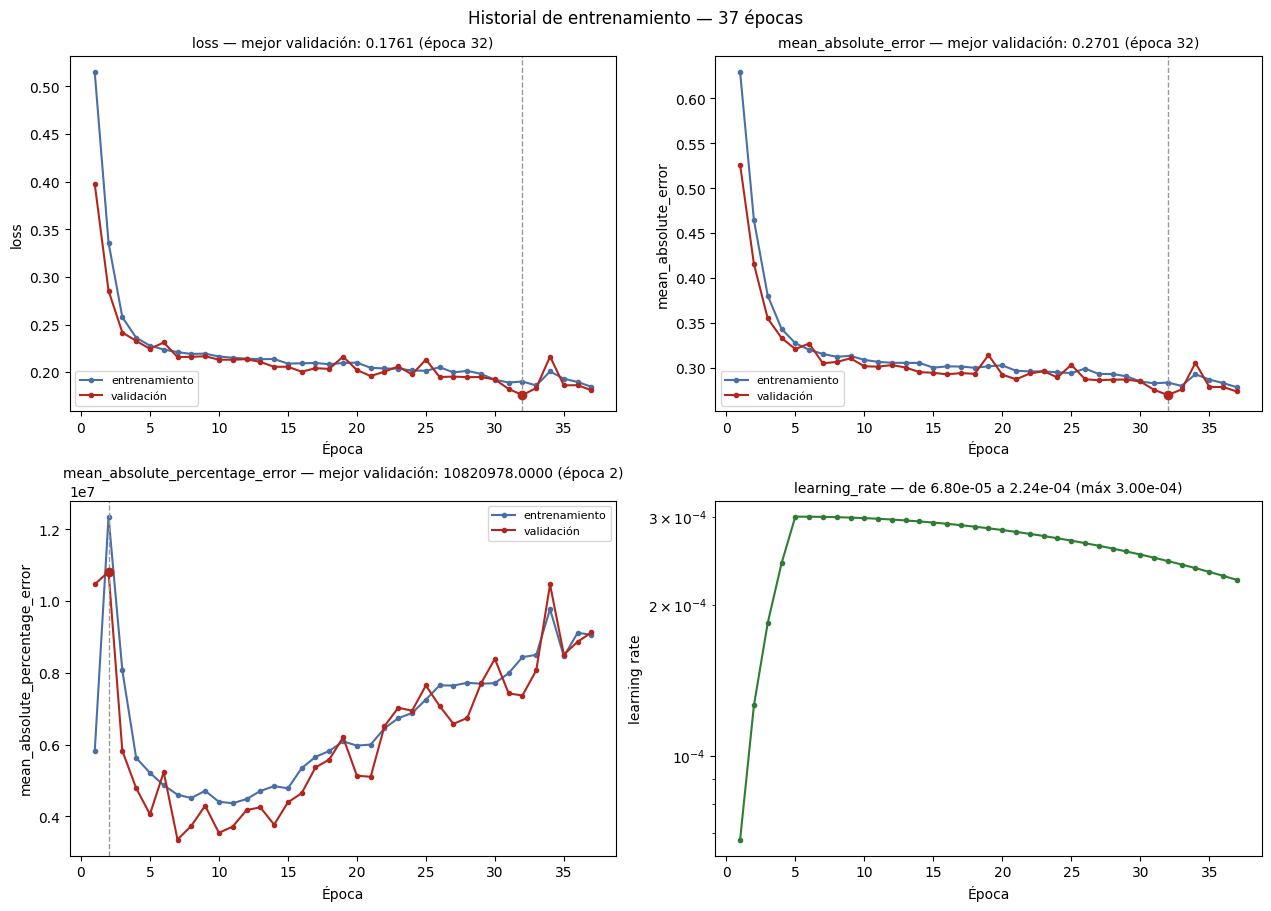

In [12]:
plot_history(history)

In [13]:
X_test = transform_pipeline.transform(anomaly_df)

X_test_window = sliding_window_view(X_test, window_shape=(WINDOW, X_test.shape[1])).squeeze()

123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step


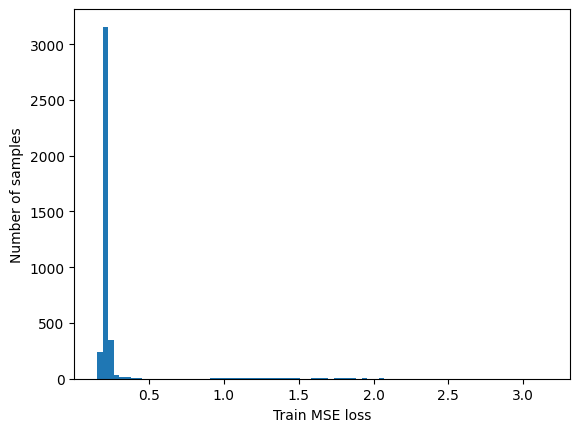

(np.float64(0.8887991850550554),
 np.float64(1.6096518030304454),
 np.float64(0.24226919148681175))

In [14]:
model.load_weights(RUTA_MODELO)
predictions_test = model.predict(X_test_window)

mse = np.mean(np.pow(predictions_test[:, 4] - X_test_window[:, 4], 2), axis=1)

plt.hist(mse, bins=80)
plt.xlabel("Train MSE loss")
plt.ylabel("Number of samples")
plt.show()

threshold_std = np.mean(mse) + 3 * np.std(mse)

threshold_percentile = np.percentile(mse, 99)

q1, q3 = np.percentile(mse, [25, 75])
iqr = q3 - q1
threshold_iqr = q3 + (1.5 * iqr)

threshold_std, threshold_percentile, threshold_iqr

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


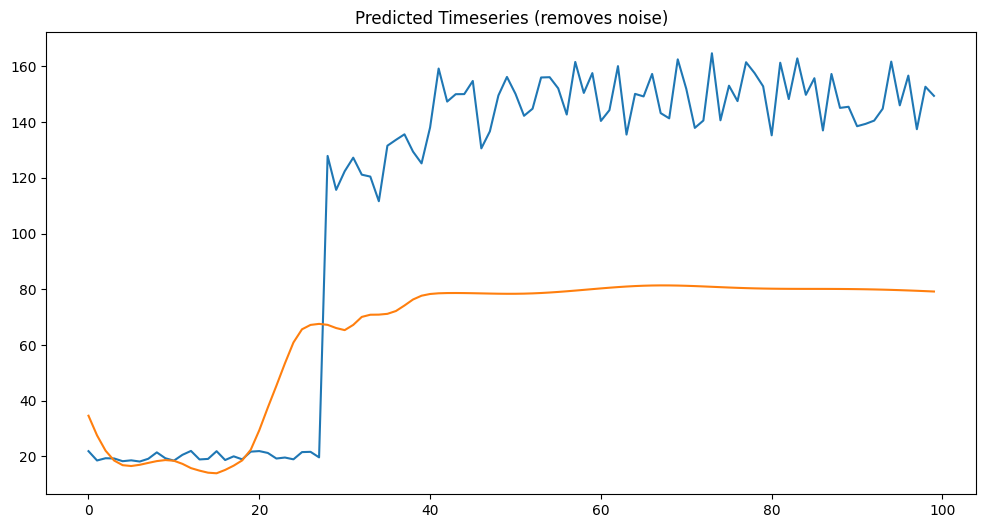

In [15]:
enc = transform_pipeline[-1]
scaler = enc.named_transformers_["value"]

k = 2960

inverse_window = scaler.inverse_transform(X_test_windows[k, :, 4:])

prediction = model.predict(X_test_windows[k][None, :])

inverse_preds = scaler.inverse_transform(prediction[0, :, 4:])

plt.figure(figsize=(12, 6))
plt.title("Predicted Timeseries (removes noise)")
plt.plot(inverse_window)
plt.plot(inverse_preds)
plt.show()

In [ ]:
n = len(anomaly_df)

n_windows = n - WINDOW + 1

X = np.asarray(transform_pipeline.transform(anomaly_df))

windows = sliding_window_view(X, WINDOW, axis=0).transpose(0, 2, 1)

windows = np.ascontiguousarray(windows[:n_windows])

preds = model.predict(windows, verbose="0")

mse = np.mean(np.pow(preds[:, :, 4] - windows[:, :, 4], 2), axis=1)

data_indices = np.arange(WINDOW - 1, n)

anomalous_data_indices1 = data_indices[mse > threshold_std]
anomalous_data_indices2 = data_indices[mse > threshold_percentile]
anomalous_data_indices3 = data_indices[mse > threshold_iqr]

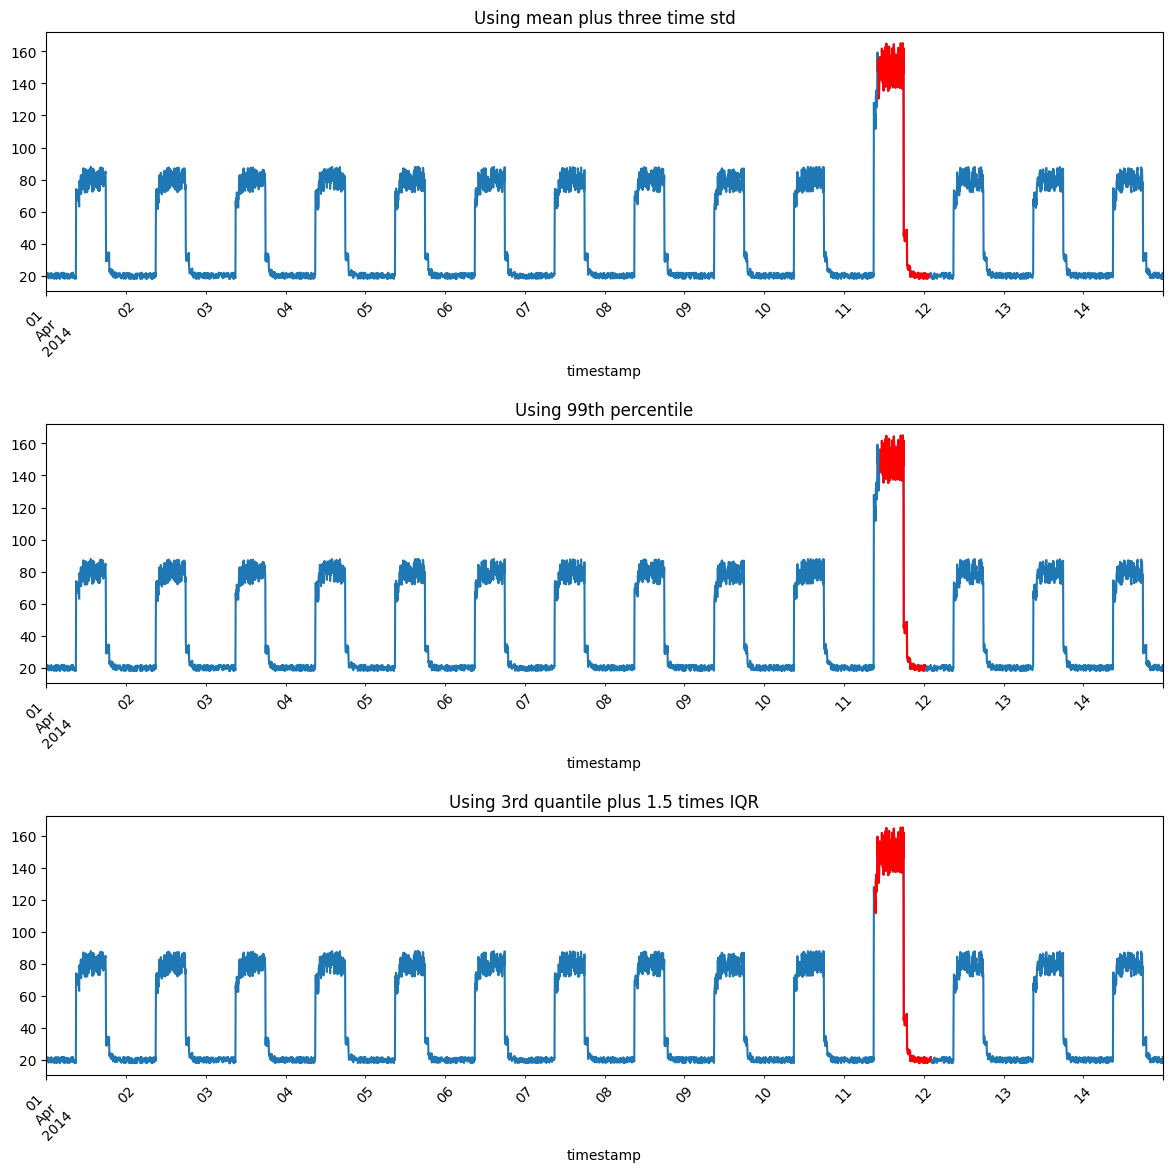

In [18]:
subset_anomalies1_df = anomaly_df.iloc[anomalous_data_indices1]
subset_anomalies2_df = anomaly_df.iloc[anomalous_data_indices2]
subset_anomalies3_df = anomaly_df.iloc[anomalous_data_indices3]

fig, ax = plt.subplots(3, 1, figsize=(12, 12))

ax[0].set_title("Using mean plus three time std")
anomaly_df.plot(
    x=anomaly_df.columns[0],
    rot=45,
    ax=ax[0],
    legend=False,
)
subset_anomalies1_df.plot(
    x=subset_anomalies1_df.columns[0],
    rot=45,
    ax=ax[0],
    color="red",
    legend=False,
)

ax[1].set_title("Using 99th percentile")
anomaly_df.plot(
    x=anomaly_df.columns[0],
    rot=45,
    ax=ax[1],
    legend=False,
)
subset_anomalies2_df.plot(
    x=subset_anomalies1_df.columns[0],
    rot=45,
    ax=ax[1],
    color="red",
    legend=False,
)

ax[2].set_title("Using 3rd quantile plus 1.5 times IQR")
anomaly_df.plot(
    x=anomaly_df.columns[0],
    rot=45,
    ax=ax[2],
    legend=False,
)
subset_anomalies3_df.plot(
    x=subset_anomalies1_df.columns[0],
    rot=45,
    ax=ax[2],
    color="red",
    legend=False,
)

plt.tight_layout(pad=1.7)
plt.show()